In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [4]:
X = np.array([
    [1, 1],
    [2, 1],
    [2, 2],
    [3, 2],
    [3, 3],   
    [5, 4],
    [6, 5],
    [7, 5],
    [7, 6],
    [8, 6]
])

y = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
])

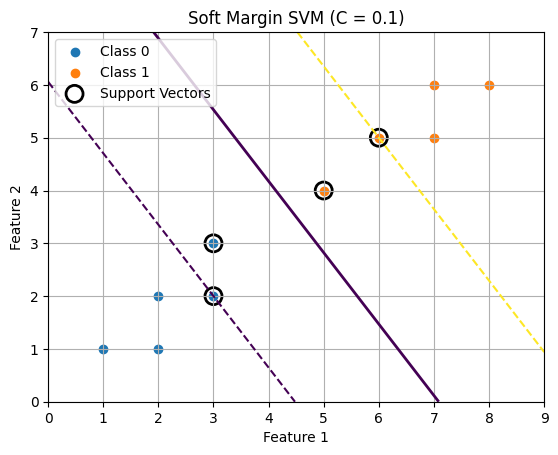

Support Vectors:
[[3. 2.]
 [3. 3.]
 [5. 4.]
 [6. 5.]]

Number of Support Vectors: 4


In [7]:
model = SVC(kernel='linear', C=0.1)

model.fit(X, y)


x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1
y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = model.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.contour(
    xx, yy, Z,
    levels=[0],
    linewidths=2
)

plt.contour(
    xx, yy, Z,
    levels=[-1, 1],
    linestyles='--'
)

plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label="Support Vectors"
)


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Soft Margin SVM (C = 0.1)")
plt.legend()
plt.grid(True)


plt.show()

print("Support Vectors:")
print(model.support_vectors_)

print("\nNumber of Support Vectors:",
      len(model.support_vectors_))